In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [74]:
df = pd.read_csv("../data/GEDEvent_v25_1.csv", low_memory=False)

In [76]:
df.drop_duplicates(inplace=True)
print(f"Número de filas: {df.shape[0]}")

Número de filas: 385918


In [77]:

# Ajustamos las variables con fecha (mantenemos 'year' como int)
df['date_start'] = pd.to_datetime(df['date_start'], errors='coerce')
df['date_end'] = pd.to_datetime(df['date_end'], errors='coerce')

In [78]:
# Mapeamos la variable nominal 'type_of_violence' a 1: state-based conflict 2: non-state conflict 3: one-sided violence
df["type_of_violence"] = df["type_of_violence"].map({1: "state-based conflict", 2: "non-state conflict", 3: "one-sided violence"}).astype("category")

#### Variables a eliminar

De acuerdo con el análisis de variables a eliminar. Sólo es cuestión de cambiar la columna 'eliminate' en el archivo `variable_names_and_descriptions.csv` según se requiera. 

In [79]:
# Se carga el análisis de las variables. 
variables=pd.read_csv("../data/variables.csv", encoding="utf-8", sep=";")


In [80]:
variables.head()

,variable_name,description,eliminate,reason_to_eliminate
0,id,Identificador unico del evento,True,Id de la observación
1,relid,Identificador interno del evento (cambia si el...,True,Id de la observación
2,year,Ano del evento,True,Copia a [date_start]
3,active_year,True si el evento pertenece a un conflicto act...,False,NaN
4,code_status,Si el registro est ok (clear) o si hay que ch...,True,Valor único (solo contiene 'clear')


In [81]:
# Se crea una lista con las variables a eliminar (True en la columna "eliminate")
cols_to_drop = variables.loc[variables["eliminate"] == True, "variable_name"].tolist()

cols_to_drop

['id',
 'relid',
 'year',
 'code_status',
 'conflict_dset_id',
 'conflict_new_id',
 'dyad_dset_id',
 'dyad_new_id',
 'side_a_dset_id',
 'side_a_new_id',
 'side_b_dset_id',
 'side_b_new_id',
 'source_article',
 'source_office',
 'source_date',
 'source_headline',
 'source_original',
 'where_description',
 'geom_wkt',
 'priogrid_gid',
 'country_id',
 'deaths_a',
 'deaths_b',
 'deaths_civilians',
 'deaths_unknown',
 'gwnoa',
 'gwnob']

In [82]:
# Se crea un nuevo dataframe con las columnas a eliminar

dfcut = df.drop(columns=cols_to_drop, errors="ignore")

In [83]:
dfcut.head(10)

,active_year,type_of_violence,conflict_name,dyad_name,side_a,side_b,number_of_sources,where_prec,where_coordinates,adm_1,...,longitude,country,region,event_clarity,date_prec,date_start,date_end,best,high,low
0,True,state-based conflict,Iraq: Government,Government of Iraq - IS,Government of Iraq,IS,3,1,Kabul city,Kabul province,...,69.162796,Afghanistan,Asia,1,1,2017-07-31,2017-07-31,6,6,6
1,True,state-based conflict,Iraq: Government,Government of Iraq - IS,Government of Iraq,IS,15,1,Kabul international airport,Kabul province,...,69.217222,Afghanistan,Asia,1,1,2021-08-26,2021-08-26,183,184,171
2,True,state-based conflict,Iraq: Government,Government of Iraq - IS,Government of Iraq,IS,5,1,Jalalabad town,Nangarhar province,...,70.455750,Afghanistan,Asia,1,1,2021-08-28,2021-08-28,2,3,0
3,True,state-based conflict,Iraq: Government,Government of Iraq - IS,Government of Iraq,IS,8,1,Kabul city,Kabul province,...,69.162796,Afghanistan,Asia,1,1,2021-08-29,2021-08-29,10,10,9
4,True,state-based conflict,Afghanistan: Government,Government of Afghanistan - Jam'iyyat-i Islami...,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,-1,4,Nangarhar province,Nangarhar province,...,70.416670,Afghanistan,Asia,1,3,1989-01-07,1989-01-13,6,6,6
5,True,state-based conflict,Afghanistan: Government,Government of Afghanistan - Jam'iyyat-i Islami...,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,-1,4,Kunduz province,Kunduz province,...,68.750000,Afghanistan,Asia,2,2,1989-01-15,1989-01-18,4,4,0
6,True,state-based conflict,Afghanistan: Government,Government of Afghanistan - Jam'iyyat-i Islami...,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,-1,1,Salang pass,Baghlan province,...,69.038889,Afghanistan,Asia,1,2,1989-01-23,1989-01-24,600,600,600
7,True,state-based conflict,Afghanistan: Government,Government of Afghanistan - Jam'iyyat-i Islami...,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,-1,1,Kabul city,Kabul province,...,69.162796,Afghanistan,Asia,1,3,1989-01-30,1989-02-05,2,2,0
8,True,state-based conflict,Afghanistan: Government,Government of Afghanistan - Jam'iyyat-i Islami...,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,-1,2,Salang tunnel,Baghlan province,...,69.038710,Afghanistan,Asia,1,1,1989-01-31,1989-01-31,70,70,70
9,True,state-based conflict,Afghanistan: Government,Government of Afghanistan - Jam'iyyat-i Islami...,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,-1,4,Hirat province,Hirat province,...,62.000000,Afghanistan,Asia,1,1,1989-02-04,1989-02-04,20,20,0


In [84]:
def dfresume(df):
    df = df.copy()
    dfresume = pd.DataFrame({
    'variable_name': df.columns,
    'dtype': df.dtypes.astype(str),
    'no nulos': df.count(),
    'unicos': df.nunique(),
    'unicos_%': (df.nunique()/df.count()*100).round(0).astype(int),
    'nulos': df.isna().sum(),
    'nulos_%': (df.isna().mean() * 100).round(0).astype(int),
    })
    dfresume.reset_index(drop=True, inplace=True)
    return dfresume

In [85]:
# Se analizan las variables resumen

df_resumen = dfresume(dfcut)

df_resumen

,variable_name,dtype,no nulos,unicos,unicos_%,nulos,nulos_%
0,active_year,bool,385918,2,0,0,0
1,type_of_violence,category,385918,3,0,0,0
2,conflict_name,object,385918,1529,0,0,0
3,dyad_name,object,385918,1771,0,0,0
4,side_a,object,385918,966,0,0,0
5,side_b,object,385918,959,0,0,0
6,number_of_sources,int64,385918,54,0,0,0
7,where_prec,int64,385918,7,0,0,0
8,where_coordinates,object,385918,54511,14,0,0
9,adm_1,object,366371,1682,0,19547,5


In [86]:
category_variables = list(dfcut.select_dtypes(include=['category', 'object']).columns)

category_variables

['type_of_violence',
 'conflict_name',
 'dyad_name',
 'side_a',
 'side_b',
 'where_coordinates',
 'adm_1',
 'adm_2',
 'country',
 'region']

In [87]:
def clean_best_est(df):
    df = df.copy()

    mask_invert = df["high"] < df["low"]
    df.loc[mask_invert, ["high", "low"]] = df.loc[mask_invert, ["low", "high"]].values

    df["best_est_cleaned"] = df["best"]

    mask_best_missing = df["best_est_cleaned"].isna() | (df["best_est_cleaned"] == 0)

    mask_both = mask_best_missing & df["low"].notna() & df["high"].notna()
    df.loc[mask_both, "best_est_cleaned"] = (df.loc[mask_both, "low"] + df.loc[mask_both, "high"]) / 2

    mask_low_only = mask_best_missing & df["low"].notna() & df["high"].isna()
    df.loc[mask_low_only, "best_est_cleaned"] = df.loc[mask_low_only, "low"]

    mask_high_only = mask_best_missing & df["high"].notna() & df["low"].isna()
    df.loc[mask_high_only, "best_est_cleaned"] = df.loc[mask_high_only, "high"]

    mask_zero_false = (df["best"] == 0) & ((df["low"] > 0) | (df["high"] > 0))
    df.loc[mask_zero_false, "best_est_cleaned"] = df[["low", "high"]].max(axis=1)

    df["best_est_cleaned"] = df["best_est_cleaned"].clip(lower=df["low"], upper=df["high"])

    return df

In [88]:
# Dataset con clean_beast_est (la mejor estimación corregida)

dfcbe = clean_best_est(dfcut)

/tmp/ipykernel_197203/528660163.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[100.  200.  300.  ...   0.5   0.5   0.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mask_both, "best_est_cleaned"] = (df.loc[mask_both, "low"] + df.loc[mask_both, "high"]) / 2


In [89]:
# Se eliminan las columnas 'best', 'high' y 'low', porque ya están contenidas 
# en la nueva variable clean_beast_est

dfcbe.drop(columns=['best', 'high', 'low'], errors="ignore", inplace=True)

In [90]:
dfcbe.head()

,active_year,type_of_violence,conflict_name,dyad_name,side_a,side_b,number_of_sources,where_prec,where_coordinates,adm_1,adm_2,latitude,longitude,country,region,event_clarity,date_prec,date_start,date_end,best_est_cleaned
0,True,state-based conflict,Iraq: Government,Government of Iraq - IS,Government of Iraq,IS,3,1,Kabul city,Kabul province,Kabul district,34.531094,69.162796,Afghanistan,Asia,1,1,2017-07-31,2017-07-31,6.0
1,True,state-based conflict,Iraq: Government,Government of Iraq - IS,Government of Iraq,IS,15,1,Kabul international airport,Kabul province,Kabul district,34.564444,69.217222,Afghanistan,Asia,1,1,2021-08-26,2021-08-26,183.0
2,True,state-based conflict,Iraq: Government,Government of Iraq - IS,Government of Iraq,IS,5,1,Jalalabad town,Nangarhar province,Jalalabad district,34.428844,70.455750,Afghanistan,Asia,1,1,2021-08-28,2021-08-28,2.0
3,True,state-based conflict,Iraq: Government,Government of Iraq - IS,Government of Iraq,IS,8,1,Kabul city,Kabul province,Kabul district,34.531094,69.162796,Afghanistan,Asia,1,1,2021-08-29,2021-08-29,10.0
4,True,state-based conflict,Afghanistan: Government,Government of Afghanistan - Jam'iyyat-i Islami...,Government of Afghanistan,Jam'iyyat-i Islami-yi Afghanistan,-1,4,Nangarhar province,Nangarhar province,NaN,34.333330,70.416670,Afghanistan,Asia,1,3,1989-01-07,1989-01-13,6.0


In [91]:
dfresume(dfcbe)

,variable_name,dtype,no nulos,unicos,unicos_%,nulos,nulos_%
0,active_year,bool,385918,2,0,0,0
1,type_of_violence,category,385918,3,0,0,0
2,conflict_name,object,385918,1529,0,0,0
3,dyad_name,object,385918,1771,0,0,0
4,side_a,object,385918,966,0,0,0
5,side_b,object,385918,959,0,0,0
6,number_of_sources,int64,385918,54,0,0,0
7,where_prec,int64,385918,7,0,0,0
8,where_coordinates,object,385918,54511,14,0,0
9,adm_1,object,366371,1682,0,19547,5


#### Antes de codificar sería bueno hacer algunas transformaciones (no estadísticas)

**Variable coordendas (latitude y longitude)**

Apunto lo siguiente: las coordenadas en grados no son lineales:

la distancia entre grados cambia según la latitud,

1 grado de longitud no vale lo mismo en el ecuador que en Noruega,

la línea de cambio de fecha rompe la continuidad (-180 vs +180).

Para un modelo lineal o una red densa, eso genera ruido y relaciones espurias.

Las coordenadas son útiles cuando se convierten a categóricas, ejemplo: barrio, municipio, zona censal, región administrativa. (Esto ya lo tiene por defecto el dataset).

**Fechas**

Una fecha completa (por ejemplo, 2024-11-23) no es útil como número secuencial, porque:

- no es lineal (diciembre no es “doce veces más” que enero),
- mezcla año, mes, día y hora en un solo valor,
- carece de interpretación para modelos lineales,
- distorsiona relaciones temporales.

La fecha solo es un contenedor de rasgos temporales que debes extraer.

Dependiendo del tipo de problema, se derivan variables que capturan patrones temporales. Aquí tienes las más usadas, y cuándo sirven.

Año: Sirve cuando el fenómeno cambia por tendencias macro (economía, conflicto, clima, participación política).

Mes: Captura estacionalidad, clima, ciclos productivos, comportamiento social, temporadas.

Día del mes: Puede capturar rutinas administrativas o eventos cíclicos.

**Variables cíclicas (transformaciones seno y coseno)** (después del split): Para mes y día de la semana, estas transformaciones son útiles:

~~~
mes_sin = sin(2π * mes/12)
mes_cos = cos(2π * mes/12)
~~~

### Transformando las fechas en información relevante:

In [92]:
# Con esta función se extrae de las variables date_start y date_end la información relevante para 
# los futuros modelos. 
# 1. Se extraen los años, meses y días (de inicio y fin) en columnas separadas
# 2. Se crea una nueva columna con la información del día de la semana correspondiente


def date_transform(df_in):

    df = df_in.copy()
    # Asegurar que las fechas estén en formato datetime
    df['date_start'] = pd.to_datetime(df['date_start'])
    df['date_end'] = pd.to_datetime(df['date_end'])

    # -------- EXTRACCIÓN DE COMPONENTES DE LA FECHA -------- #

    # Mes
    df['start_month'] = df['date_start'].dt.month
    df['end_month'] = df['date_end'].dt.month

    # Día del mes
    df['start_day'] = df['date_start'].dt.day
    df['end_day'] = df['date_end'].dt.day

    # Año
    df['start_year'] = df['date_start'].dt.year
    df['end_year'] = df['date_end'].dt.year

    # -------- DÍA DE LA SEMANA DENTRO DEL MES -------- #
    # (Ej: segundo lunes del mes → día de la semana en el mes = 2)

    def weekday_in_month(series):
        return ((series.dt.day - 1) // 7) + 1

    df['start_weekday_in_month'] = weekday_in_month(df['date_start'])
    df['end_weekday_in_month'] = weekday_in_month(df['date_end'])

    # -------- DURACIÓN DEL EVENTO -------- #
    # diferencia en días
    df['duration_days'] = (df['date_end'] - df['date_start']).dt.days

    # si la duración es 0, la convertimos en 1
    df['duration_days'] = df['duration_days'].replace(0, 1)

    return df

In [93]:
# Función para transformar en numericos cíclicos los meses 
# Se transforman las nuevas columnas de meses en valores cíclicos con funciones seno y coseno
# Es para usar después del split

def cyclic_month_transformer(df_in, month_cols):
    df = df_in.copy()
    for col in month_cols:

        if col not in df.columns:
            raise ValueError(f"La columna '{col}' no existe en el dataframe.")

        if df[col].min() < 1 or df[col].max() > 12:
            raise ValueError(f"La columna '{col}' debe contener valores entre 1 y 12.")

        df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / 12)
        df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / 12)
    
    return df

In [94]:
dftemp = date_transform(dfcbe)
dftemp.drop(columns=['date_start', 'date_end'], errors="ignore", inplace=True)

In [95]:
dfresume(dftemp)

,variable_name,dtype,no nulos,unicos,unicos_%,nulos,nulos_%
0,active_year,bool,385918,2,0,0,0
1,type_of_violence,category,385918,3,0,0,0
2,conflict_name,object,385918,1529,0,0,0
3,dyad_name,object,385918,1771,0,0,0
4,side_a,object,385918,966,0,0,0
5,side_b,object,385918,959,0,0,0
6,number_of_sources,int64,385918,54,0,0,0
7,where_prec,int64,385918,7,0,0,0
8,where_coordinates,object,385918,54511,14,0,0
9,adm_1,object,366371,1682,0,19547,5


#### Crear la variable objetivo `lethality_class`

De acuerdo con los siguientes rangos:


| Clase |	Rango (muertes)	| Interpretación |
| ----- | ----------------- | -------------- |
| Baja | 0 – 5 |	Violencia localizada |
| Media	| 6 – 20	| Ataques moderados |
| Alta	| > 20	| Eventos masivos / intensos |

In [96]:
# Definición de los límites
bins = [-np.inf, 5, 20, np.inf]
labels = ['Baja', 'Media', 'Alta']

dftemp['lethality_class'] = pd.cut(dftemp['best_est_cleaned'], 
                               bins=bins, 
                               labels=labels, 
                               right=True)
dfresume(dftemp)

,variable_name,dtype,no nulos,unicos,unicos_%,nulos,nulos_%
0,active_year,bool,385918,2,0,0,0
1,type_of_violence,category,385918,3,0,0,0
2,conflict_name,object,385918,1529,0,0,0
3,dyad_name,object,385918,1771,0,0,0
4,side_a,object,385918,966,0,0,0
5,side_b,object,385918,959,0,0,0
6,number_of_sources,int64,385918,54,0,0,0
7,where_prec,int64,385918,7,0,0,0
8,where_coordinates,object,385918,54511,14,0,0
9,adm_1,object,366371,1682,0,19547,5


## Seleccioń de técnicas de codificación

Analizando la cardinalidad de las variables categóricas, que tienen entre 959 y 54511 datos únicos, a continuación se presentan algunas técnicas que se manejan con alta cardinalidad:

- CatBoost Encoding: cardinalidad muy alta, depende del target... cuidado con el leakage
- Hashing Encoding (HashEncoder): cardinalidad alta, garantiza cero leakage porque no depende del target
- Binary encodig: cardinalidad media
- OneHot encoding: cardinalidad baja

| Variable          | datos únicos | Técnica seleccionada  |
| ----------------- | ------------ | --------------------- |
| conflict_name     | 1529         |  CatBoost             |
| dyad_name         | 1771         |  CatBoost             |
| adm_1             | 1682         |  CatBoost             |
| adm_2             | 9366         |  Hashing              |
| side_a            | 966          |  CatBoost             |
| side_b            | 959          |  CatBoost             |
| where_coordinates | 54511        |  Hashing              |
| country           | 124          |  Binary,              |
| region            | 5            |  One-hot              |
| type_of_violence  | 3            |  One-hot              |


**Criterio**

- Alta cardinalidad pero sin semántica → Hashing Encoder

- Alta cardinalidad con semántica y dependiente del target → CatBoost Encoder

- Baja cardinalidad nominal → OneHot

- Baja cardinalidad pero uniforme → Binary




#### División en train, test y validation

In [97]:
# División del dataset en train, validation and test. 

from sklearn.model_selection import train_test_split

X = dftemp.drop(columns=['lethality_class'], errors='ignore')
y = dftemp['lethality_class']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42, 
                                                    stratify=y
                                                    )

X_val, X_test, y_val, y_test = train_test_split(X_temp, 
                                                y_temp, 
                                                test_size=0.5, 
                                                random_state=42, 
                                                stratify=y_temp
                                                )

In [98]:
# Clase para volver cíclico el mes

from sklearn.base import BaseEstimator, TransformerMixin

class CyclicMonthTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        import numpy as np
        X = X.copy()

        for col in X.columns:
            X[f"{col}_sin"] = np.sin(2*np.pi*X[col] / 12)
            X[f"{col}_cos"] = np.cos(2*np.pi*X[col] / 12)

        return X[[c for c in X.columns if c.endswith("_sin") or c.endswith("_cos")]]



In [101]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from category_encoders import CatBoostEncoder, HashingEncoder, BinaryEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
# from sklearn.ensemble import RandomForestClassifier

# Columnas por tipo
binary_cols = ["country"] 
hash_cols = ["adm_2", "where_coordinates"]
catboost_cols = ["dyad_name", "adm_1", "conflict_name", "side_a", "side_b"]
onehot_cols = ["region", "type_of_violence"]
numeric_cols = [
    "best_est_cleaned", "start_month", "end_month",
    "start_day", "end_day", "start_year", "end_year",
    "start_weekday_in_month", "end_weekday_in_month",
    "duration_days"
]
month_cols = ["start_month", "end_month"]

preprocess = ColumnTransformer(
    transformers=[
        ("numeric_scaler", StandardScaler(), numeric_cols),
        ("binary", BinaryEncoder(), binary_cols),
        ("hash", HashingEncoder(n_components=128), hash_cols), # n_components moderadamente alto para no perdr información
        ("catboost", CatBoostEncoder(random_state=95), catboost_cols),
        ("onehot", OneHotEncoder(handle_unknown='ignore'), onehot_cols),
        ("month_cyclic", CyclicMonthTransformer(), month_cols)
    ],
    remainder='passthrough'
)

pipeline = Pipeline([
    ("preprocess", preprocess)
    #("model", RandomForestClassifier())
])


In [102]:
# Ajustar el pipeline SOLO con X_train
pipeline.fit(X_train, y_train)

# Transformar los datos
X_train_trans = pipeline.transform(X_train)



## Reducción de dimensionalidad


Se reduce dimensionalidad con PCA, que debe recibir las variables codificadas y luego se transforman a componentes ortogonales (PCA).

- Captura la máxima varianza lineal posible.
- Es útil para entender si, después del encoding, las clases muestran separabilidad aproximada.


PCA no captura relaciones no lineales, por eso se complementa con UMAP.

/tmp/ipykernel_197203/3635890280.py:17: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca[:,0], X_pca[:,1], c=y_colors, s=5, alpha=0.6, cmap="viridis")


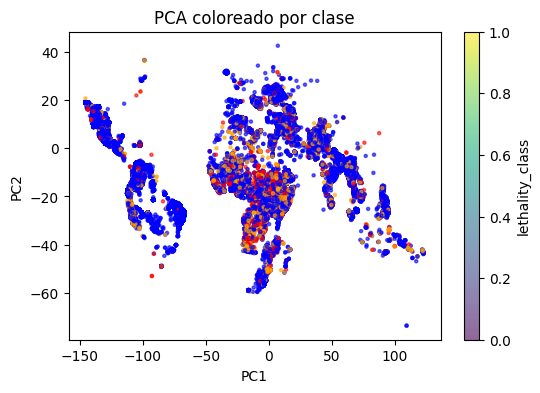

In [103]:
# PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_trans)

class_map = {"Baja":0, "Media":1, "Alta":2}

y_num = y_train.map(class_map)

# Paleta
palette = np.array(["blue", "orange", "red"])
y_colors = palette[y_num.values]

plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_colors, s=5, alpha=0.6, cmap="viridis")
plt.title("PCA coloreado por clase")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="lethality_class")
plt.show()



In [ ]:
#  UMAP (Uniform Manifold Approximation and Projection)

import umap

umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_train_trans)

plt.figure(figsize=(8,6))
plt.scatter(umap_train[:,0], umap_train[:,1], c=y_colors, s=5, alpha=0.5)
plt.title("UMAP coloreado por letalidad")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

/home/luis/Luis/1_MIAE/0_Clases/2_AdD/repoTP/tp_analisis_de_datos/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/luis/Luis/1_MIAE/0_Clases/2_AdD/repoTP/tp_analisis_de_datos/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
